In [42]:
!pip install understatapi pandas --quiet

In [43]:
import pandas as pd
import understatapi

client = understatapi.UnderstatClient()

league = client.league(league='EPL')
matches = league.get_match_data(season='2025')

df = pd.DataFrame(matches)

In [44]:
shot_data = client.match(match='29136').get_shot_data()
shot_data

{'h': [{'id': '684803',
   'minute': '25',
   'result': 'BlockedShot',
   'X': '0.905',
   'Y': '0.6530000305175782',
   'xG': '0.11693864315748215',
   'player': 'Mathys Tel',
   'h_a': 'h',
   'player_id': '9780',
   'situation': 'OpenPlay',
   'season': '2025',
   'shotType': 'RightFoot',
   'match_id': '29136',
   'h_team': 'Tottenham',
   'a_team': 'Leeds',
   'h_goals': '1',
   'a_goals': '1',
   'date': '2026-05-11 19:00:00',
   'player_assisted': 'Rodrigo Bentancur',
   'lastAction': 'TakeOn'},
  {'id': '684804',
   'minute': '27',
   'result': 'BlockedShot',
   'X': '0.85',
   'Y': '0.4859999847412109',
   'xG': '0.07059775292873383',
   'player': 'Conor Gallagher',
   'h_a': 'h',
   'player_id': '9040',
   'situation': 'OpenPlay',
   'season': '2025',
   'shotType': 'RightFoot',
   'match_id': '29136',
   'h_team': 'Tottenham',
   'a_team': 'Leeds',
   'h_goals': '1',
   'a_goals': '1',
   'date': '2026-05-11 19:00:00',
   'player_assisted': None,
   'lastAction': 'None'},
  

In [45]:
type(shot_data)

dict

In [46]:
shot_data.keys()

dict_keys(['h', 'a'])

In [47]:
import pandas as pd

df = pd.DataFrame(shot_data['h'] + shot_data['a'])

df[['X','Y','xG','minute']] = df[['X','Y','xG','minute']].astype(float)

df.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,684803,25.0,BlockedShot,0.905,0.653,0.116939,Mathys Tel,h,9780,OpenPlay,2025,RightFoot,29136,Tottenham,Leeds,1,1,2026-05-11 19:00:00,Rodrigo Bentancur,TakeOn
1,684804,27.0,BlockedShot,0.850,0.486,0.070598,Conor Gallagher,h,9040,OpenPlay,2025,RightFoot,29136,Tottenham,Leeds,1,1,2026-05-11 19:00:00,None,None
2,684805,31.0,SavedShot,0.911,0.524,0.110063,Richarlison,h,6026,OpenPlay,2025,RightFoot,29136,Tottenham,Leeds,1,1,2026-05-11 19:00:00,Pedro Porro,Cross
3,684806,32.0,BlockedShot,0.933,0.517,0.127807,Rodrigo Bentancur,h,6108,FromCorner,2025,RightFoot,29136,Tottenham,Leeds,1,1,2026-05-11 19:00:00,Mathys Tel,Cross
4,684807,32.0,MissedShots,0.919,0.514,0.113606,Richarlison,h,6026,FromCorner,2025,LeftFoot,29136,Tottenham,Leeds,1,1,2026-05-11 19:00:00,None,None


In [81]:
df.to_csv("tottenham_vs_leeds.csv", index=False)

In [82]:
from google.colab import files

files.download("tottenham_vs_leeds.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
print(df.columns)

Index(['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team',
       'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction'],
      dtype='object')


In [49]:
print(df[['X','Y']].head())

       X      Y
0  0.905  0.653
1  0.850  0.486
2  0.911  0.524
3  0.933  0.517
4  0.919  0.514


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               27 non-null     object 
 1   minute           27 non-null     float64
 2   result           27 non-null     object 
 3   X                27 non-null     float64
 4   Y                27 non-null     float64
 5   xG               27 non-null     float64
 6   player           27 non-null     object 
 7   h_a              27 non-null     object 
 8   player_id        27 non-null     object 
 9   situation        27 non-null     object 
 10  season           27 non-null     object 
 11  shotType         27 non-null     object 
 12  match_id         27 non-null     object 
 13  h_team           27 non-null     object 
 14  a_team           27 non-null     object 
 15  h_goals          27 non-null     object 
 16  a_goals          27 non-null     object 
 17  date             2

# Q1: Which team created higher-quality chances in the match?

In [51]:
# Create a team column
df["team"] = df.apply(
    lambda row: row["h_team"] if row["h_a"] == "h" else row["a_team"],
    axis=1
)

# Total xG per team
team_xg = df.groupby("team")["xG"].sum().sort_values(ascending=False)

print(team_xg)

team
Leeds        1.869763
Tottenham    1.498572
Name: xG, dtype: float64


# Total xG

In [52]:
df.groupby("team")["xG"].sum()

,xG
team,
Leeds,1.869763
Tottenham,1.498572


# Number of Shots

In [53]:
df.groupby("team")["id"].count()

,id
team,
Leeds,11
Tottenham,16


# Average xG per Shot

In [54]:
df.groupby("team")["xG"].mean()

,xG
team,
Leeds,0.169978
Tottenham,0.093661


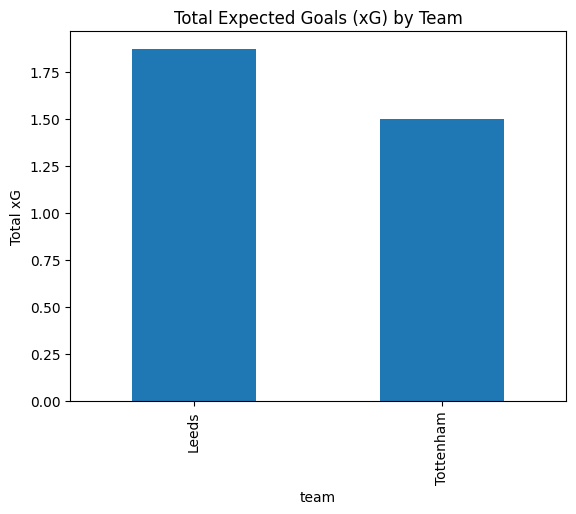

In [55]:
import matplotlib.pyplot as plt

team_xg.plot(kind="bar")
plt.title("Total Expected Goals (xG) by Team")
plt.ylabel("Total xG")
plt.show()

# Key Insight
Leeds created better chances overall

Even though the match outcome (goals) might suggest something else, the underlying chance quality tells a different story:

Leeds generated ~0.37 more xG than Tottenham
This suggests Leeds had more dangerous or higher-quality shooting opportunities
Tottenham, despite being a strong side, created lower-value chances on average

# Q2: Which players were most efficient in chance conversion?

In [56]:
import numpy as np

# Create goal column (1 if goal, 0 otherwise)
df["goal"] = df["result"].apply(lambda x: 1 if x == "Goal" else 0)

# Aggregate by player
player_perf = df.groupby("player").agg(
    shots=("id", "count"),
    xG=("xG", "sum"),
    goals=("goal", "sum")
)

# Efficiency metric
player_perf["xG_diff"] = player_perf["goals"] - player_perf["xG"]
player_perf["conversion_rate"] = player_perf["goals"] / player_perf["shots"]

# Sort by efficiency
player_perf = player_perf.sort_values("xG_diff", ascending=False)

player_perf

,shots,xG,goals,xG_diff,conversion_rate
player,,,,,
Mathys Tel,2,0.141535,1,0.858465,0.5
Dominic Calvert-Lewin,2,0.778792,1,0.221208,0.5
Anton Stach,1,0.016406,0,-0.016406,0.0
James Justin,1,0.019883,0,-0.019883,0.0
Daniel James,1,0.021558,0,-0.021558,0.0
Pascal Struijk,1,0.041105,0,-0.041105,0.0
Kevin Danso,1,0.044992,0,-0.044992,0.0
Ao Tanaka,1,0.057437,0,-0.057437,0.0
Lucas Bergvall,1,0.057445,0,-0.057445,0.0


# ⚽ Q2 Insight: Which players were most efficient in chance conversion?
🟢 Top Performers (Overperforming xG)
🔥 Mathys Tel
Shots: 2
xG: 0.14
Goals: 1
xG difference: +0.86 (massive overperformance)

👉 Interpretation:

Extremely clinical finishing in low-xG situations
Likely scored from a difficult chance
Could indicate:
High finishing skill OR
Small sample variance (important caution)
🔥 Dominic Calvert-Lewin
Shots: 2
xG: 0.78
Goals: 1
xG difference: +0.22

👉 Interpretation:

Created/received high-quality chance(s)
Finished as expected or slightly above expectation
More sustainable performance signal than Tel (because xG is higher and sample is more realistic)
🟡 Neutral / Expected Performers

No major “neutral” players besides the two scorers — most others didn’t score.

🔴 Underperformers (Wasteful or Unlucky Finishing)
❌ Richarlison
Shots: 4 (highest in match)
xG: 0.75
Goals: 0
xG difference: -0.75

👉 Interpretation:

Biggest attacking underperformance in the match
Had multiple decent chances but failed to convert
This is a key scouting signal:
Could indicate poor finishing form
OR good positioning but finishing issue
❌ Sean Longstaff
Shots: 2
xG: 0.62
Goals: 0
xG difference: -0.62

👉 Interpretation:

High-quality chances missed
Likely had at least one big opportunity
❌ Other midfield/defensive shooters

Players like:

João Palhinha
Bentancur
Porro

👉 Pattern:

Low xG shots from distance or low-quality zones
Expected non-scoring outcomes → not necessarily “bad finishing”
🧠 Key Tactical Insight
⚖️ The match shows a clear imbalance:
Tottenham had:
More shooters (Richarlison, Bentancur, Porro, etc.)
But poor conversion efficiency
Leeds had:
Fewer high-volume attackers
But slightly more clinical finishing moments (Tel, Calvert-Lewin)

# From which game situations were most dangerous chances created?

# Aggregate xG by Situation

In [57]:
situation_xg = df.groupby("situation").agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).sort_values("total_xG", ascending=False)

situation_xg

,total_xG,shots
situation,,
OpenPlay,1.554127,16
FromCorner,1.009902,9
Penalty,0.761169,1
DirectFreekick,0.043138,1


In [58]:
situation_xg["xG_per_shot"] = situation_xg["total_xG"] / situation_xg["shots"]
situation_xg

,total_xG,shots,xG_per_shot
situation,,,
OpenPlay,1.554127,16,0.097133
FromCorner,1.009902,9,0.112211
Penalty,0.761169,1,0.761169
DirectFreekick,0.043138,1,0.043138


# 🧠 Key Tactical Insights
🔵 1. Open Play = Main source of chance creation
Highest shot volume (16 shots)
Highest total xG (1.55)

👉 Interpretation:

Both teams rely heavily on structured attacking play
This reflects:
Build-up sequences
Positional attacks
Final-third progression

⚽ Scouting meaning:

The match was not set-piece dependent — chance creation was driven by open-play structure.

🟡 2. Set Pieces (Corners) = Highly efficient danger source
9 shots → 1.01 xG
Higher xG per shot than open play (0.112 vs 0.097)

👉 Interpretation:

Corners produced better quality chances than open play
Even with fewer shots, they were more dangerous per attempt

⚽ Scouting meaning:

Defensive set-piece vulnerability or strong aerial threat was present.

🔴 3. Penalty = High-impact isolated event
1 shot → 0.76 xG

👉 Interpretation:

Expected (penalties always high xG)
Skews total attacking output slightly

⚽ Scouting meaning:

One decisive moment contributed significantly to match xG profile.

⚪ 4. Direct Free Kicks = Negligible threat
Very low xG (0.04)

👉 Interpretation:

No real danger from direct set-piece shooting attempts
Likely poor execution or long-distance attempts
📊 Big Picture Tactical Story
⚖️ Match Identity

This game was defined by:

🔵 Open play dominance in volume
🟡 Corners as the most efficient structured set-piece threat
🔴 Penalties influencing xG disproportionately
⚪ Free kicks not impactful

In [59]:
team_situation = df.groupby(["team", "situation"]).agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).reset_index()

team_situation.sort_values(["team", "total_xG"], ascending=[True, False])

,team,situation,total_xG,shots
2,Leeds,Penalty,0.761169,1
0,Leeds,FromCorner,0.577181,2
1,Leeds,OpenPlay,0.531413,8
5,Tottenham,OpenPlay,1.022714,8
4,Tottenham,FromCorner,0.432720,7
3,Tottenham,DirectFreekick,0.043138,1


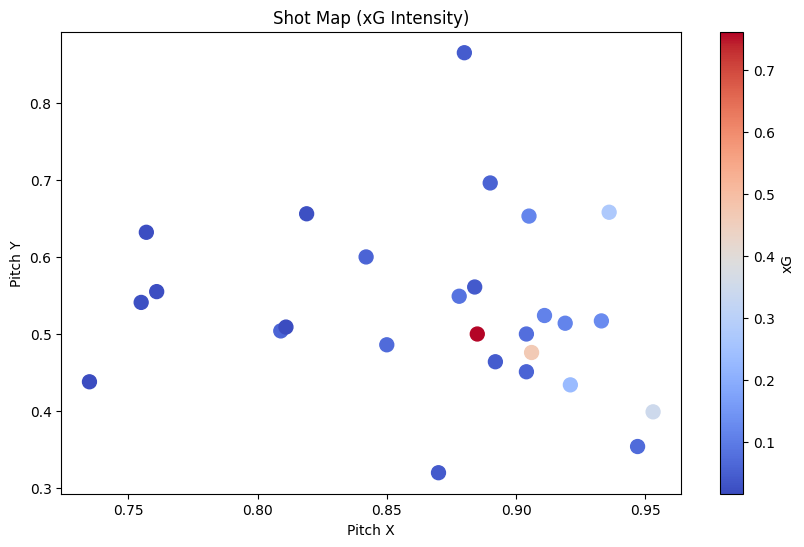

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df["X"], df["Y"], c=df["xG"], cmap="coolwarm", s=100)

plt.title("Shot Map (xG Intensity)")
plt.xlabel("Pitch X")
plt.ylabel("Pitch Y")
plt.colorbar(label="xG")

plt.show()

In [61]:
player_situation = df.groupby(["team","player", "situation","result"]).agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).reset_index()

player_situation.sort_values("total_xG", ascending=False)

,team,player,situation,result,total_xG,shots
4,Leeds,Dominic Calvert-Lewin,Penalty,Goal,0.761169,1
23,Tottenham,Richarlison,OpenPlay,MissedShots,0.467171,1
9,Leeds,Sean Longstaff,FromCorner,MissedShots,0.347523,1
10,Leeds,Sean Longstaff,OpenPlay,SavedShot,0.272662,1
6,Leeds,Joe Rodon,FromCorner,SavedShot,0.229658,1
25,Tottenham,Rodrigo Bentancur,FromCorner,BlockedShot,0.127807,1
18,Tottenham,Mathys Tel,OpenPlay,BlockedShot,0.116939,1
21,Tottenham,Richarlison,FromCorner,MissedShots,0.113606,1
24,Tottenham,Richarlison,OpenPlay,SavedShot,0.110063,1
7,Leeds,Lukas Nmecha,OpenPlay,SavedShot,0.084739,1


# Q4: What types of shots generated the highest expected value?

In [62]:
shottype_xg = df.groupby("shotType").agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).sort_values("total_xG", ascending=False)

shottype_xg

,total_xG,shots
shotType,,
RightFoot,2.382917,16
LeftFoot,0.612520,7
Head,0.372898,4


In [63]:
shottype_xg["xG_per_shot"] = shottype_xg["total_xG"] / shottype_xg["shots"]
shottype_xg

,total_xG,shots,xG_per_shot
shotType,,,
RightFoot,2.382917,16,0.148932
LeftFoot,0.612520,7,0.087503
Head,0.372898,4,0.093225


# Q5: Where on the pitch were the most dangerous shots taken?

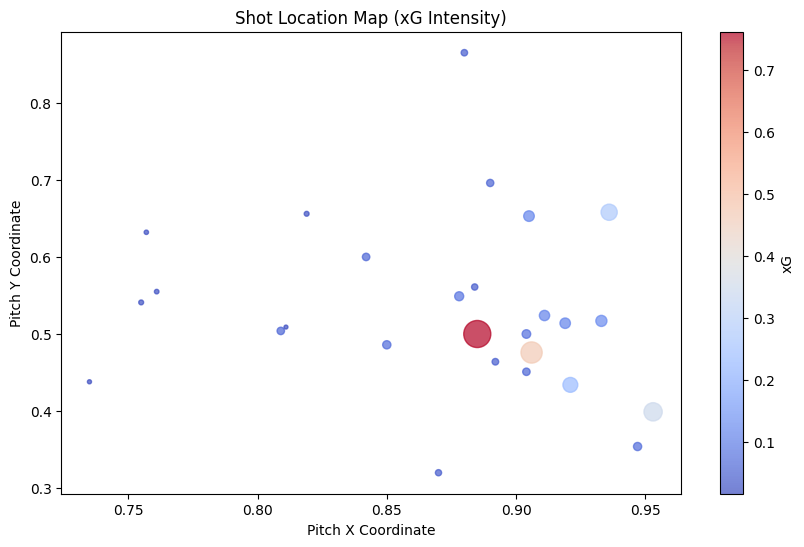

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["X"],
    df["Y"],
    c=df["xG"],
    s=df["xG"] * 500,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Shot Location Map (xG Intensity)")
plt.xlabel("Pitch X Coordinate")
plt.ylabel("Pitch Y Coordinate")

plt.colorbar(label="xG")

plt.show()

In [67]:
shots_counts= df.groupby(["h_a","player", "X","Y","xG"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

   h_a                 player      X      Y        xG       result  shots
0    a            Anton Stach  0.811  0.509  0.016406  MissedShots      1
1    a              Ao Tanaka  0.809  0.504  0.057437  MissedShots      1
2    a           Daniel James  0.761  0.555  0.021558  MissedShots      1
3    a  Dominic Calvert-Lewin  0.735  0.438  0.017623  MissedShots      1
4    a  Dominic Calvert-Lewin  0.885  0.500  0.761169         Goal      1
5    a           James Justin  0.757  0.632  0.019883  BlockedShot      1
6    a              Joe Rodon  0.921  0.434  0.229658    SavedShot      1
7    a           Lukas Nmecha  0.878  0.549  0.084739    SavedShot      1
8    a         Pascal Struijk  0.884  0.561  0.041105  MissedShots      1
9    a         Sean Longstaff  0.936  0.658  0.272662    SavedShot      1
10   a         Sean Longstaff  0.953  0.399  0.347523  MissedShots      1
11   h        Conor Gallagher  0.755  0.541  0.024644  BlockedShot      1
12   h        Conor Gallagher  0.850  

In [68]:
shots_counts= df.groupby(["h_a","player", "X","Y","xG","situation"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

   h_a                 player      X      Y        xG       situation  \
0    a            Anton Stach  0.811  0.509  0.016406        OpenPlay   
1    a              Ao Tanaka  0.809  0.504  0.057437        OpenPlay   
2    a           Daniel James  0.761  0.555  0.021558        OpenPlay   
3    a  Dominic Calvert-Lewin  0.735  0.438  0.017623        OpenPlay   
4    a  Dominic Calvert-Lewin  0.885  0.500  0.761169         Penalty   
5    a           James Justin  0.757  0.632  0.019883        OpenPlay   
6    a              Joe Rodon  0.921  0.434  0.229658      FromCorner   
7    a           Lukas Nmecha  0.878  0.549  0.084739        OpenPlay   
8    a         Pascal Struijk  0.884  0.561  0.041105        OpenPlay   
9    a         Sean Longstaff  0.936  0.658  0.272662        OpenPlay   
10   a         Sean Longstaff  0.953  0.399  0.347523      FromCorner   
11   h        Conor Gallagher  0.755  0.541  0.024644      FromCorner   
12   h        Conor Gallagher  0.850  0.486  0.0705

In [65]:
pip install mplsoccer

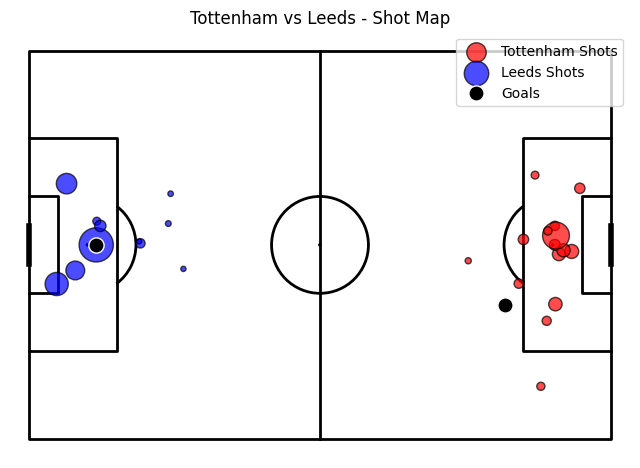

In [72]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch setup
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Convert coordinates
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# Split teams (IMPORTANT: use .copy())
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Flip away team coordinates (attacking direction fix)
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# Plot shots by team
# -----------------------------
for d, color, label in [
    (home, 'red', 'Tottenham Shots'),
    (away, 'blue', 'Leeds Shots')
]:
    ax.scatter(
        d['x'], d['y'],
        s=d['xG'] * 800,
        alpha=0.7,
        c=color,
        edgecolors='black',
        label=label
    )

# -----------------------------
# Highlight goals
# -----------------------------
goals = df[df['result'] == 'Goal'].copy()

# Apply same flip logic for away goals
goals.loc[goals['h_a'] == 'a', 'x'] = 120 - goals.loc[goals['h_a'] == 'a', 'x']
goals.loc[goals['h_a'] == 'a', 'y'] = 80 - goals.loc[goals['h_a'] == 'a', 'y']

ax.scatter(
    goals['x'], goals['y'],
    c='black',
    s=120,
    edgecolors='white',
    label='Goals',
    zorder=3
)

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Tottenham vs Leeds - Shot Map", fontsize=12)
plt.legend()
plt.show()

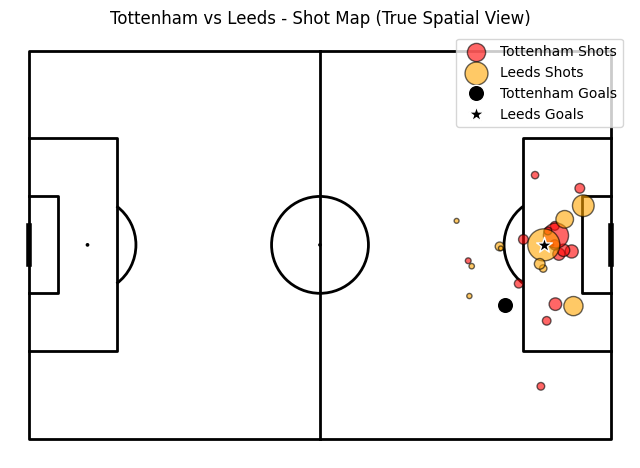

In [73]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Convert coordinates
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# Split teams safely
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Plot home team
# -----------------------------
ax.scatter(
    home['x'], home['y'],
    s=home['xG'] * 700,
    c='red',
    alpha=0.6,
    edgecolors='black',
    label='Tottenham Shots'
)

# -----------------------------
# Plot away team
# -----------------------------
ax.scatter(
    away['x'], away['y'],
    s=away['xG'] * 700,
    c='orange',
    alpha=0.6,
    edgecolors='black',
    label='Leeds Shots'
)

# -----------------------------
# Goals (kept team-aware)
# -----------------------------
home_goals = home[home['result'] == 'Goal']
away_goals = away[away['result'] == 'Goal']

ax.scatter(
    home_goals['x'], home_goals['y'],
    c='black',
    s=140,
    edgecolors='white',
    zorder=3,
    label='Tottenham Goals'
)

ax.scatter(
    away_goals['x'], away_goals['y'],
    c='black',
    s=140,
    edgecolors='white',
    marker='*',
    zorder=3,
    label='Leeds Goals'
)

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Tottenham vs Leeds - Shot Map (True Spatial View)", fontsize=12)
plt.legend()
plt.show()

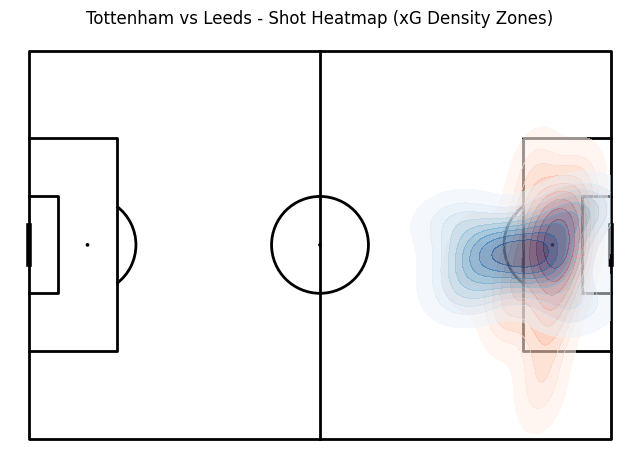

In [74]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Prepare data
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

home = df[df['h_a'] == 'h']
away = df[df['h_a'] == 'a']

# -----------------------------
# Heatmap: Home team
# -----------------------------
pitch.kdeplot(
    home['x'],
    home['y'],
    ax=ax,
    fill=True,
    cmap='Reds',
    alpha=0.6,
    label='Home Heatmap'
)

# -----------------------------
# Heatmap: Away team
# -----------------------------
pitch.kdeplot(
    away['x'],
    away['y'],
    ax=ax,
    fill=True,
    cmap='Blues',
    alpha=0.5,
    label='Away Heatmap'
)

# -----------------------------
# Title
# -----------------------------
plt.title("Tottenham vs Leeds - Shot Heatmap (xG Density Zones)")
plt.show()

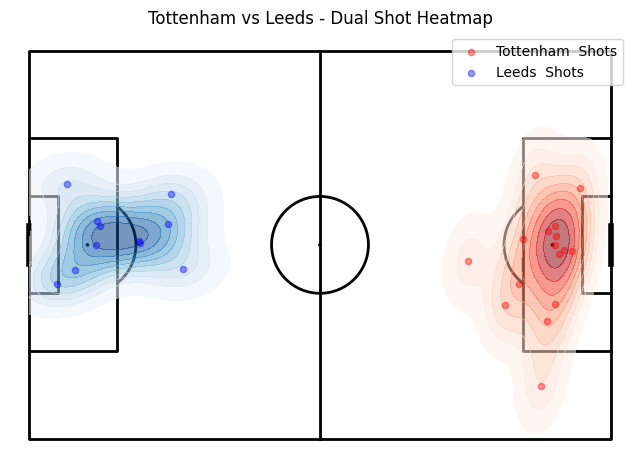

In [77]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Prepare data
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Flip ONLY away team (so both attack same direction visually)
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# Combine for heatmaps per team
# -----------------------------
pitch.kdeplot(
    home['x'],
    home['y'],
    ax=ax,
    fill=True,
    cmap='Reds',
    alpha=0.55
)

pitch.kdeplot(
    away['x'],
    away['y'],
    ax=ax,
    fill=True,
    cmap='Blues',
    alpha=0.55
)

# -----------------------------
# Optional: overlay shot points (for clarity)
# -----------------------------
ax.scatter(home['x'], home['y'], c='red', s=20, alpha=0.4, label='Tottenham  Shots')
ax.scatter(away['x'], away['y'], c='blue', s=20, alpha=0.4, label='Leeds  Shots')

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Tottenham vs Leeds - Dual Shot Heatmap")
plt.legend()
plt.show()

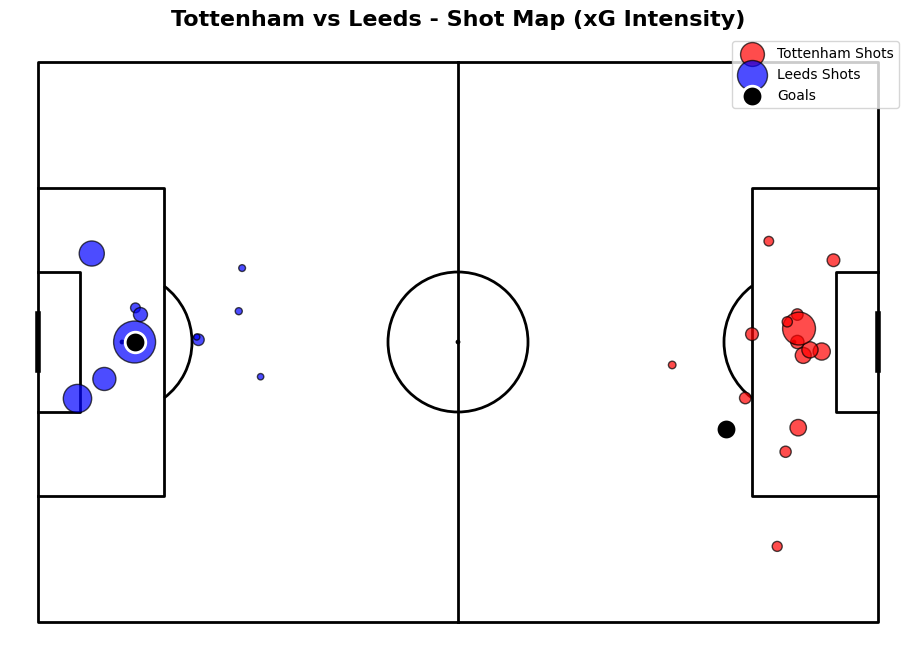

In [79]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# COPY DATA
# -----------------------------
df = df.copy()

# -----------------------------
# CONVERT UNDERSTAT COORDINATES
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# SPLIT TEAMS
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# FLIP AWAY TEAM
# IMPORTANT
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# TEAM NAMES
# -----------------------------
home_team = df['h_team'].iloc[0]
away_team = df['a_team'].iloc[0]

# -----------------------------
# CREATE PITCH
# -----------------------------
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black'
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# -----------------------------
# HOME SHOTS
# -----------------------------
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 1200,
    color='red',
    edgecolors='black',
    alpha=0.7,
    label=f'{home_team} Shots'
)

# -----------------------------
# AWAY SHOTS
# -----------------------------
ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 1200,
    color='blue',
    edgecolors='black',
    alpha=0.7,
    label=f'{away_team} Shots'
)

# -----------------------------
# GOALS
# -----------------------------
goals = df[df['result'] == 'Goal'].copy()

# Flip away goals too
away_goals = goals[goals['h_a'] == 'a'].copy()
away_goals['x'] = 120 - (away_goals['X'] * 120)
away_goals['y'] = 80 - (away_goals['Y'] * 80)

home_goals = goals[goals['h_a'] == 'h'].copy()
home_goals['x'] = home_goals['X'] * 120
home_goals['y'] = home_goals['Y'] * 80

goal_plot = pd.concat([home_goals, away_goals])

ax.scatter(
    goal_plot['x'],
    goal_plot['y'],
    s=220,
    color='black',
    edgecolors='white',
    linewidth=2,
    zorder=5,
    label='Goals'
)

# -----------------------------
# TITLE
# -----------------------------
plt.title(
    f'{home_team} vs {away_team} - Shot Map (xG Intensity)',
    fontsize=16,
    fontweight='bold'
)

plt.legend()
plt.show()

In [83]:
plt.savefig("shot_map.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [84]:
files.download("shot_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

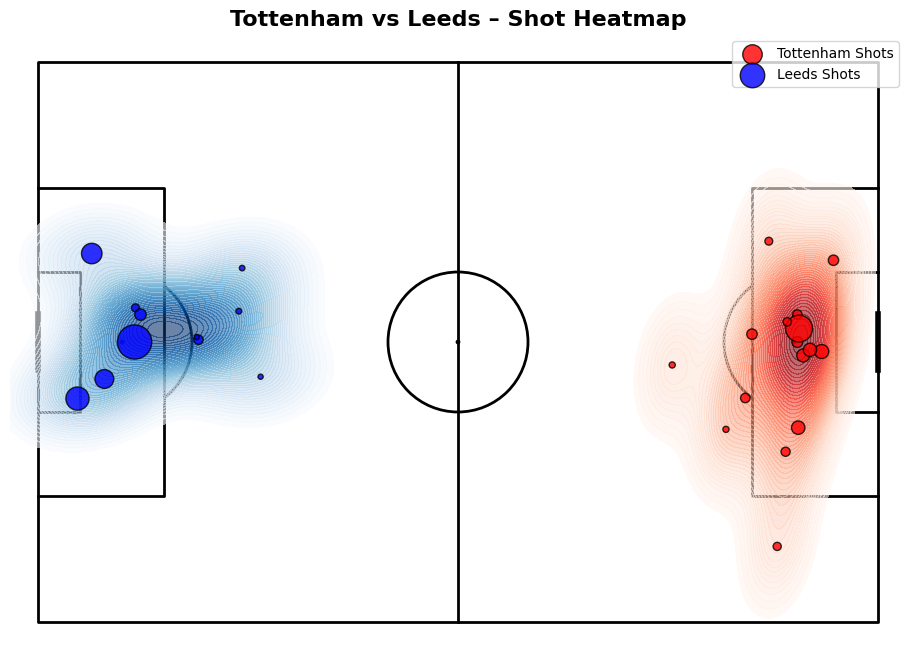

In [80]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# COPY DATA
# -----------------------------
df = df.copy()

# -----------------------------
# CONVERT UNDERSTAT COORDINATES
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# SPLIT TEAMS
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# FLIP AWAY TEAM
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# TEAM NAMES
# -----------------------------
home_team = df['h_team'].iloc[0]
away_team = df['a_team'].iloc[0]

# -----------------------------
# CREATE PITCH
# -----------------------------
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black',
    linewidth=2
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# -----------------------------
# HOME TEAM HEATMAP
# -----------------------------
sns.kdeplot(
    x=home['x'],
    y=home['y'],
    fill=True,
    cmap='Reds',
    alpha=0.6,
    levels=50,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# AWAY TEAM HEATMAP
# -----------------------------
sns.kdeplot(
    x=away['x'],
    y=away['y'],
    fill=True,
    cmap='Blues',
    alpha=0.6,
    levels=50,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# OPTIONAL: ADD SHOT POINTS
# -----------------------------
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 800,
    color='red',
    edgecolors='black',
    alpha=0.8,
    label=f'{home_team} Shots'
)

ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 800,
    color='blue',
    edgecolors='black',
    alpha=0.8,
    label=f'{away_team} Shots'
)

# -----------------------------
# TITLE
# -----------------------------
plt.title(
    f'{home_team} vs {away_team} – Shot Heatmap',
    fontsize=16,
    fontweight='bold'
)

plt.legend(loc='upper right')
plt.show()

In [85]:
plt.savefig("heat_map.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [86]:
files.download("heat_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>